# ***HEART DISEASE PREDICTION PROJECT***

This project aims to analyze the patient health data and build machine learning models to predict the presence of heart disease.
The project includes:
1. Exploratory Data Analytics
2. Model Building
3. Model Comparison
4. Insights & Suggestions

## Task 1:-Prepare a complete data analysis report on the given data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
values=pd.read_csv("values.csv")
values

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [3]:
labels=pd.read_csv("labels.csv")
labels

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [4]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [5]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


The dataset contains patient medical records and corresponding labels indicating heart disease presence.

In [6]:
df=pd.merge(values,labels,on="patient_id")
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [7]:
df.drop("patient_id", axis=1, inplace=True)
df.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [8]:
df.shape

(180, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

The dataset contains both numerical and categorical features.

In [10]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


Statistical summary shows the distribution of numerical features.

In [11]:
df.isnull().sum()

slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

There are no null values in the dataset.

In [12]:
df.duplicated().sum()

np.int64(0)

Also there are no duplicate values in the dataset.

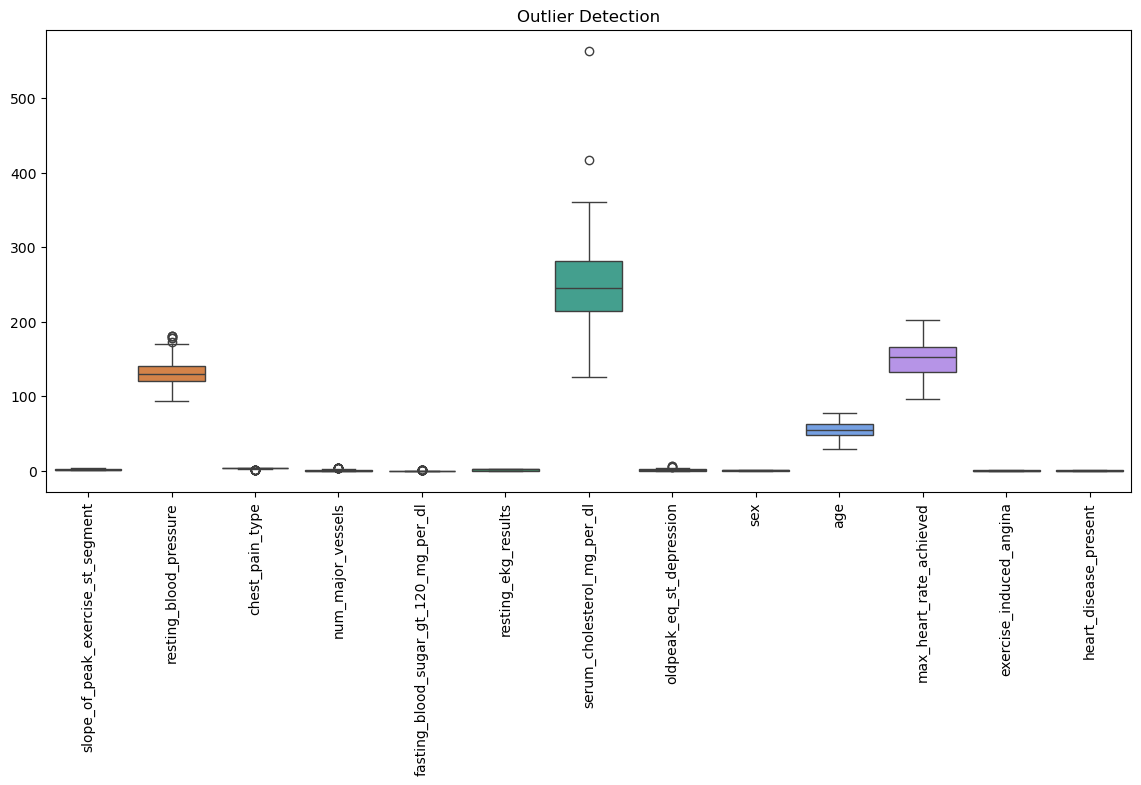

In [13]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

Outlier Analysis:

The boxplot is used to detect the outliers in the dataset. Some features such as cholesterol and resting blood pressure shows the extreme values.

However, in healthcare datasets, these outliers may represent real patient conditions rather than errors.
So, outliers are  not removed to preserve important medical information.

In [14]:
df.select_dtypes(include="object").columns

Index(['thal'], dtype='object')

In [15]:
df['thal'].value_counts()

thal
normal               98
reversible_defect    74
fixed_defect          8
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['thal']=le.fit_transform(df['thal'])

In [17]:
df['thal'].value_counts()

thal
1    98
2    74
0     8
Name: count, dtype: int64

Categorical Variable 'thal' is encoded into numerical format.

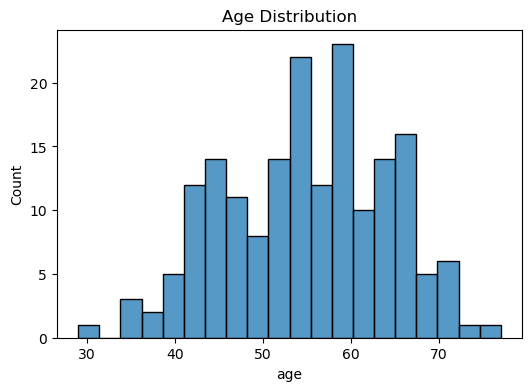

In [18]:
# AGE DISTRIBUTION
plt.figure(figsize=(6,4))
sns.histplot(df["age"],bins=20)
plt.title("Age Distribution")
plt.show()

Most patients fall into middle and older age groups, indicating higher heart disease risk with age.

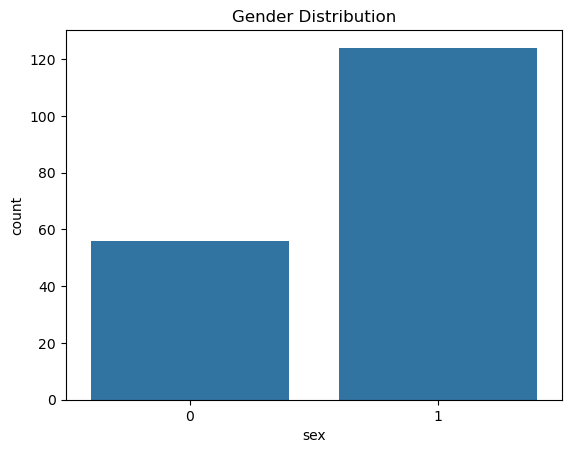

In [19]:
# GENDER DISTRIBUTION
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

Male patients are more in number compared to female patients.

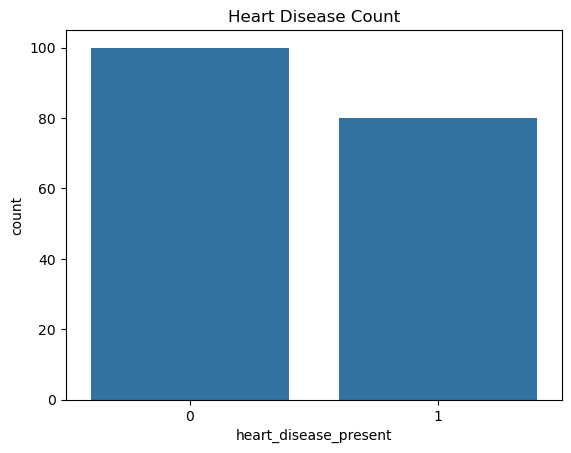

In [20]:
# TARGET VARIABLE
sns.countplot(x="heart_disease_present", data=df)
plt.title("Heart Disease Count")
plt.show()

This shows distribution of patients with and without heart disease.

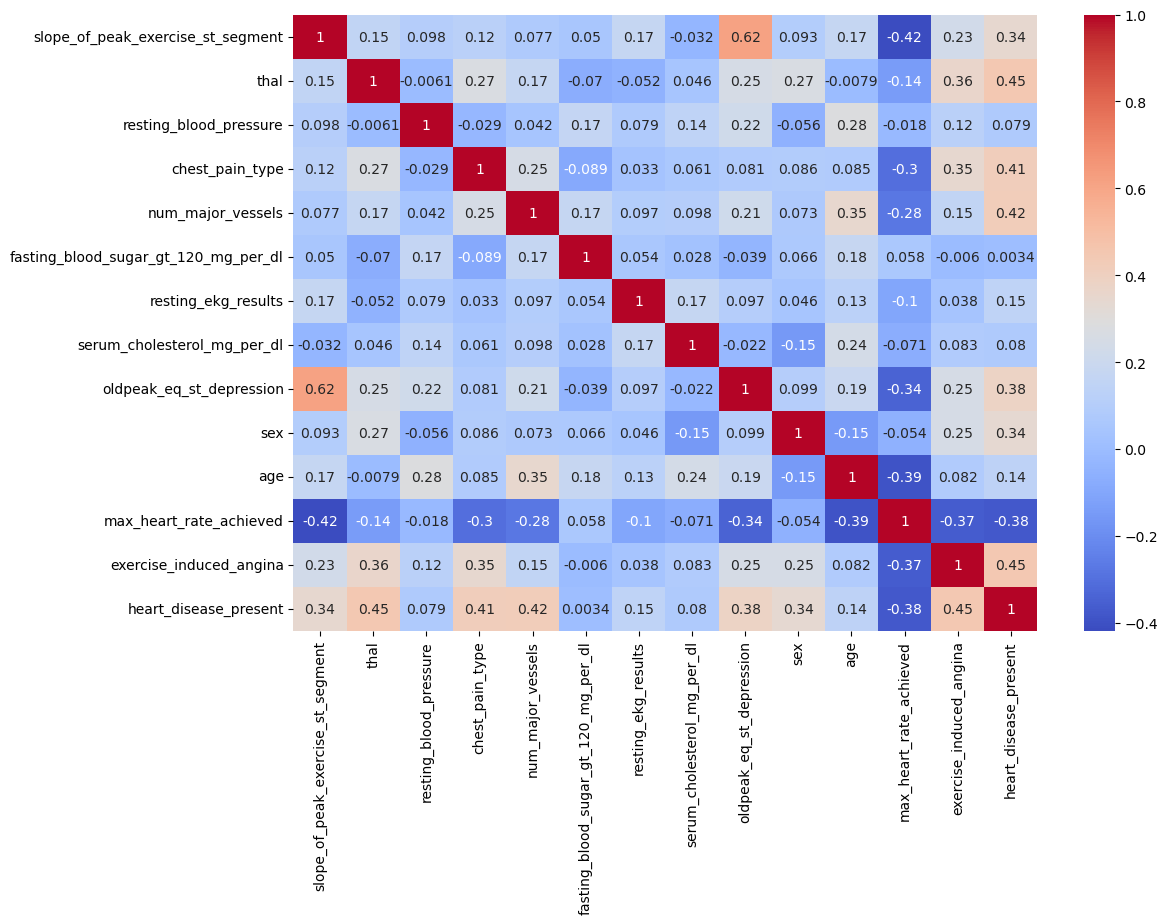

In [21]:
# CORRELATION HEATMAP
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

The correlation heatmap shows the relationship between features and the target variable. Some features like chest pain type, max heart rate, and exercise-induced angina show noticeable correlation with heart disease, indicating their importance.

Most features are not highly correlated with each other, which means there is low multicollinearity in the dataset.

The 'coolwarm' color map is used to clearly distinguish positive (red) and negative (blue) correlations, making the visualization easy to interpret.

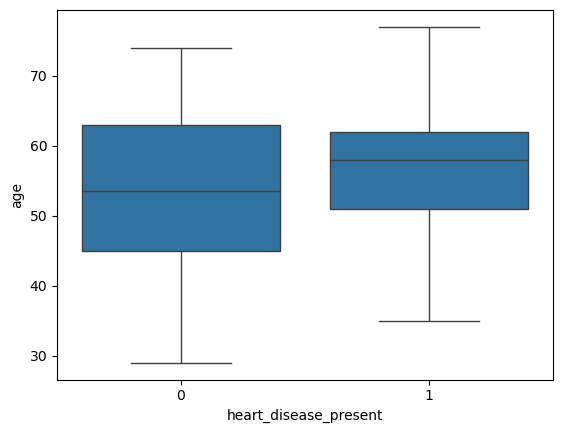

In [22]:
# AGE vs HEART DISEASE
sns.boxplot(x='heart_disease_present', y='age', data=df)
plt.show()

Patient with higher age tend to have more heart disease.

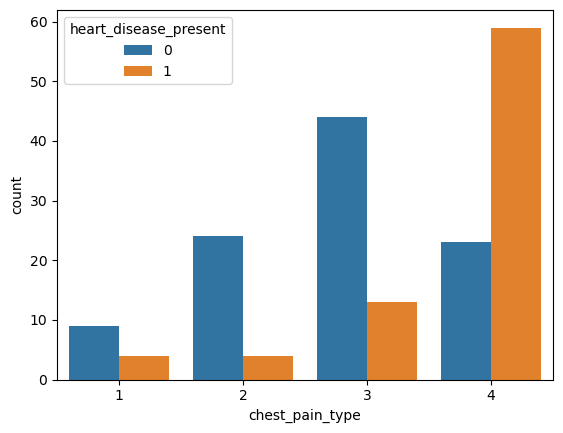

In [23]:
# CHEST PAIN vs HEART DISEASE
sns.countplot(x='chest_pain_type', hue='heart_disease_present', data=df)
plt.show()

Certain chest pain types are strongly associated with heart disease.

### Key Points:

1. Age plays a major role in heart disease.
2. Chest pain type strongly indicates heart disease.
3. Exercise-induced angina increases risk.
4. Cholesterol levels affects the heart health.
5. Some features show strong correlation with the target.

## Task 2:- Create a model predicting potential Heart Diseases in people using Machine Learning algorithms.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

In [26]:
# LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test,pred_lr)
acc_lr

0.8055555555555556

In [27]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test,pred_dt)
acc_dt

0.7777777777777778

In [28]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test,pred_rf)
acc_rf

0.8611111111111112

In [29]:
# KNN Model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test,pred_knn)
acc_knn

0.5277777777777778

In [30]:
# SVM Model
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test,pred_svm)
acc_svm

0.4722222222222222

In [31]:
# Model Comparison
models = pd.DataFrame({
'Model': ['Logistic Regression','Decision Tree','Random Forest','KNN','SVM'],
'Accuracy':[acc_lr,acc_dt,acc_rf,acc_knn,acc_svm]
})

models.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
2,Random Forest,0.861111
0,Logistic Regression,0.805556
1,Decision Tree,0.777778
3,KNN,0.527778
4,SVM,0.472222


Random Forest shows the highest accuracy and is selected as the best model for heart disease prediction.

## Task3:-Suggestions to the Hospital to awake the predictions of heart diseases prevent life threats.

Based on the analysis and model predictions, the following suggestions can help in early detection and prevention of heart diseases:

1. Conduct regular health screenings for patients, especially those above 40 years of age.
2. Monitor key health indicators such as blood pressure, cholesterol levels, and heart rate regularly.
3. Identify high-risk patients using machine learning models for early diagnosis.
4. Encourage patients to adopt a healthy lifestyle, including proper diet, exercise, and avoiding smoking.
5. Provide awareness programs about symptoms and risk factors of heart disease.
6. Focus on patients with chest pain and exercise-induced angina, as they show higher risk.
7. Implement preventive care strategies to reduce life-threatening situations.

These measures can help in early detection, timely treatment, and reduction of heart disease-related risks.

## Model Comparison Report

Multiple machine learning models were trained and evaluated on the dataset to predict heart disease.

The models used include:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

Each model was evaluated based on accuracy score on the test dataset.

Among all models, Random Forest achieved the highest accuracy compared to other models. It also handles feature interactions well and reduces overfitting through ensemble learning.

Therefore, Random Forest is selected as the best model for production as it provides better performance and generalization on unseen data.

## Report on Challenges faced

During the project, several challenges were encountered while working with the dataset:

1. Handling Categorical Data  
   The 'thal' feature was categorical and could not be used directly in machine learning models.  
   Technique Used: Label Encoding was applied to convert it into numerical form.  
   Reason: ML algorithms require numerical input for processing.

2. Understanding Feature Relationships  
   It was difficult to identify which features significantly affect heart disease.  
   Technique Used: Correlation heatmap and visualization techniques were used.  
   Reason: Helps in identifying important features and relationships.

3. Presence of Outliers  
   Some features showed extreme values which could affect model performance.  
   Technique Used: Boxplot was used for outlier detection.  
   Reason: To analyze whether outliers are errors or valid medical data. Outliers were retained as they may represent real patient conditions.

4. Model Selection  
   Choosing the best model among multiple algorithms was challenging.  
   Technique Used: Model comparison using accuracy score.  
   Reason: Helps in selecting the most suitable model based on performance.

5. Data Quality Assurance  
   Ensuring the dataset was clean and consistent.  
   Technique Used: Checked for missing values and duplicates.  
   Reason: Clean data improves model accuracy and reliability.

Overall, appropriate preprocessing and analysis techniques were applied to handle these challenges and improve model performance.